<a href="https://colab.research.google.com/github/MOHAMEDAAKIFASRAR/EX-6-NN/blob/main/NN_EXP_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Accuracy: 0.9853658536585366

Confusion Matrix:
[[102   0]
 [  3 100]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



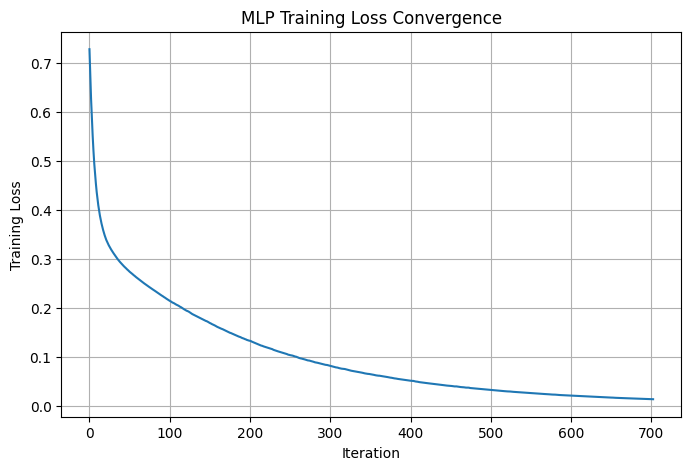

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Load Heart Disease dataset directly from GitHub
url = "/content/heart.csv"
data = pd.read_csv(url)

print("Dataset shape:", data.shape)
display(data.head())

# Separate features and target
X = data.drop("target", axis=1)
y = data["target"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train MLP classifier
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(64,),
    max_iter=1000,
    random_state=42
)

mlp_classifier.fit(X_train_scaled, y_train)

# Predictions
y_pred = mlp_classifier.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Classification Report
classification_rep = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(classification_rep)

# Plot training loss convergence
training_loss = mlp_classifier.loss_curve_

plt.figure(figsize=(8, 5))
plt.plot(training_loss)
plt.title("MLP Training Loss Convergence")
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.grid(True)
plt.show()
